# EmoExpress: AI Image Generation

## Objective

This notebook generates a personalized supportive image using the image
prompt created by the RAG and LLM response-generation pipeline.

The implementation will:

1. Load a previously generated EmoExpress response.
2. Extract its image prompt and encouraging caption.
3. Validate and strengthen the image prompt.
4. Generate an image using the OpenAI image API.
5. Save the generated image locally.
6. Display the image together with its caption.

Import libraries

In [2]:
from pathlib import Path
from datetime import datetime
import base64
import json
import os
import re
import time

from IPython.display import Image, display
from dotenv import load_dotenv
from openai import OpenAI

Configure paths and API access

In [4]:
PROJECT_ROOT = Path.cwd().parent

GENERATED_RESPONSE_DIR = (PROJECT_ROOT/ "outputs"/ "generated_responses")

GENERATED_IMAGE_DIR = (PROJECT_ROOT/ "outputs"/ "generated_images")

GENERATED_IMAGE_DIR.mkdir(parents=True,exist_ok=True)

load_dotenv(PROJECT_ROOT / ".env")

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

if not OPENAI_API_KEY:
    raise ValueError("OPENAI_API_KEY was not found in the .env file.")

client = OpenAI(api_key=OPENAI_API_KEY)

# print("Generated response directory:", GENERATED_RESPONSE_DIR)
# print("Generated image directory:", GENERATED_IMAGE_DIR)

Load the output from the LLM Response 

In [5]:
response_path = (GENERATED_RESPONSE_DIR/ "sample_rag_llm_output.json")

if not response_path.exists():
    raise FileNotFoundError("Run 03_RAG_and_LLM_Response_Generation.ipynb first. "
        f"Missing file: {response_path}")

with open(response_path,"r",encoding="utf-8") as file:
    generated_response = json.load(file)

generated_response

{'empathetic_response': "I'm really sorry to hear about your job search struggles. It's completely normal to feel disappointed and question your abilities after facing rejections. Remember, this doesn't define your worth or potential.",
 'recommendations': [{'recommendation': 'Consider seeking feedback on your applications to identify areas for improvement.',
   'source_title': None,
   'page': None},
  {'recommendation': 'Try to connect with a mentor or join a support group for job seekers.',
   'source_title': None,
   'page': None},
  {'recommendation': 'Focus on your strengths and accomplishments to boost your self-confidence.',
   'source_title': None,
   'page': None}],
 'caption': 'Every rejection brings you closer to the right opportunity.',
 'image_prompt': 'A sunrise over a mountain, symbolizing hope and new beginnings.',
 'retrieval_status': 'not_grounded',
 'sources': [],
 'retrieval_strategy': 'all_topics',
 'retrieval_query': 'User situation:I have applied to many jobs, b

Extract the required fields:

In [6]:
image_prompt = generated_response.get("image_prompt","").strip()

caption = generated_response.get("caption","").strip()

if not image_prompt:
    raise ValueError("The generated response does not contain an image prompt.")

print("IMAGE PROMPT")
print(image_prompt)

print("\nCAPTION")
print(caption)

IMAGE PROMPT
A sunrise over a mountain, symbolizing hope and new beginnings.

CAPTION
Every rejection brings you closer to the right opportunity.


**Create a safe prompt-enhancement function**

The LLM already generated the main prompt. This function adds consistent visual and safety instructions without changing its meaning.

In [15]:
def prepare_image_prompt(image_prompt):
    """
    Add consistent style and safety requirements to the
    image prompt generated by the LLM.
    """
    if not isinstance(image_prompt, str):
        raise TypeError("image_prompt must be a string.")

    image_prompt = image_prompt.strip()

    if not image_prompt:
        raise ValueError("image_prompt cannot be empty.")

    requirements = """
Create a polished, emotionally supportive digital illustration.

Visual requirements:
- communicate emotional progress, encouragement, and realistic hope;
- use symbolic imagery rather than showing a specific identifiable person;
- use a calm, balanced composition;
- make the scene suitable for an emotional-wellness application;
- do not include words, captions, logos, watermarks, or interface elements;
- do not depict self-harm, violence, graphic distress, medication,
  medical treatment, or clinical diagnosis;
- do not make exaggerated promises that everything is immediately fixed.
""".strip()
    return f"""
MAIN SCENE

{image_prompt}

ADDITIONAL REQUIREMENTS

{requirements}
""".strip()

Prepare the final prompt:

In [16]:
final_image_prompt = prepare_image_prompt(image_prompt)

print(final_image_prompt)

MAIN SCENE

A sunrise over a mountain, symbolizing hope and new beginnings.

ADDITIONAL REQUIREMENTS

Create a polished, emotionally supportive digital illustration.

Visual requirements:
- communicate emotional progress, encouragement, and realistic hope;
- use symbolic imagery rather than showing a specific identifiable person;
- use a calm, balanced composition;
- make the scene suitable for an emotional-wellness application;
- do not include words, captions, logos, watermarks, or interface elements;
- do not depict self-harm, violence, graphic distress, medication,
  medical treatment, or clinical diagnosis;
- do not make exaggerated promises that everything is immediately fixed.


Create a safe filename helper

In [17]:
def create_safe_filename(caption,extension="png"):
    """
    Create a readable filename from the generated caption.
    """

    safe_caption = re.sub(r"[^a-zA-Z0-9]+","_",caption.lower()).strip("_")

    if not safe_caption:
        safe_caption = "emoexpress_image"

    safe_caption = safe_caption[:50]

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S"    )

    return (f"{safe_caption}_{timestamp}.{extension}"    )

Create the image-generation function

In [18]:
IMAGE_MODEL = "gpt-image-1"
IMAGE_SIZE = "1024x1024"
IMAGE_QUALITY = "medium"

In [19]:
def generate_supportive_image(prompt,
                            client,
                            output_directory,
                            caption="",
                            model=IMAGE_MODEL,
                            size=IMAGE_SIZE,
                            quality=IMAGE_QUALITY):
    """
    Generate, decode, and save one supportive image.
    """

    if not prompt or not prompt.strip():
        raise ValueError("A non-empty image prompt is required.")

    start_time = time.perf_counter()

    response = client.images.generate(model=model,
                                    prompt=prompt,
                                    size=size,
                                    quality=quality,
                                    n=1)

    generation_time = (time.perf_counter() - start_time)

    if not response.data:
        raise RuntimeError("The image API returned no image data.")

    encoded_image = response.data[0].b64_json

    if not encoded_image:
        raise RuntimeError("The image response did not contain Base64 data.")

    image_bytes = base64.b64decode(encoded_image)

    file_name = create_safe_filename(caption=caption,extension="png")

    image_path = (Path(output_directory)/ file_name)

    with open(image_path,"wb") as file:
        file.write(image_bytes)

    return {"image_path": str(image_path),
        "model": model,
        "size": size,
        "quality": quality,
        "generation_time_seconds": float(generation_time),
        "prompt": prompt,
        "caption": caption}

**Generate the image**

In [20]:
image_result = generate_supportive_image(prompt=final_image_prompt,
                                        client=client,
                                        output_directory=GENERATED_IMAGE_DIR,
                                        caption=caption)

image_result

{'image_path': 'd:\\FullStack_Academic\\Final Capstone\\EmoExpress\\outputs\\generated_images\\every_rejection_brings_you_closer_to_the_right_opp_20260803_172908.png',
 'model': 'gpt-image-1',
 'size': '1024x1024',
 'quality': 'medium',
 'generation_time_seconds': 16.548117799684405,
 'prompt': 'MAIN SCENE\n\nA sunrise over a mountain, symbolizing hope and new beginnings.\n\nADDITIONAL REQUIREMENTS\n\nCreate a polished, emotionally supportive digital illustration.\n\nVisual requirements:\n- communicate emotional progress, encouragement, and realistic hope;\n- use symbolic imagery rather than showing a specific identifiable person;\n- use a calm, balanced composition;\n- make the scene suitable for an emotional-wellness application;\n- do not include words, captions, logos, watermarks, or interface elements;\n- do not depict self-harm, violence, graphic distress, medication,\n  medical treatment, or clinical diagnosis;\n- do not make exaggerated promises that everything is immediately f

Display the result

Caption:
Every rejection brings you closer to the right opportunity.

Generation time: 16.55 seconds

Saved image: d:\FullStack_Academic\Final Capstone\EmoExpress\outputs\generated_images\every_rejection_brings_you_closer_to_the_right_opp_20260803_172908.png


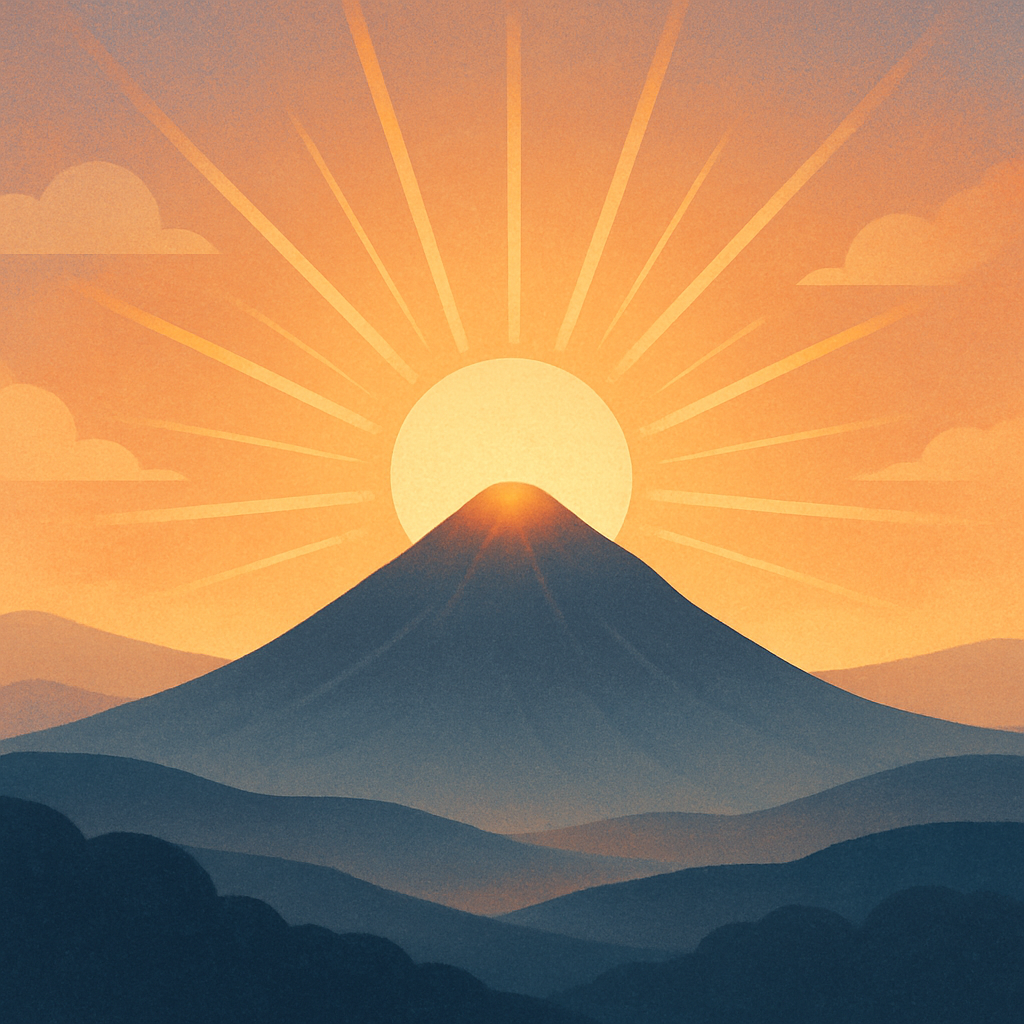

In [21]:
print("Caption:")
print(image_result["caption"])

print("\nGeneration time:",round(image_result["generation_time_seconds"],2),"seconds")

print("\nSaved image:",image_result["image_path"])

display(Image(filename=image_result["image_path"],width=600))

Save the image metadata

In [23]:
image_metadata_path = Path(image_result["image_path"]).with_suffix(".json")

with open(image_metadata_path,"w",encoding="utf-8") as file:
    json.dump(image_result,file,ensure_ascii=False,indent=4)

# print("Saved image metadata:",image_metadata_path)

Add the image information to the full response

In [24]:
complete_emoexpress_output = (generated_response.copy())

complete_emoexpress_output["generated_image"] = {"path": image_result["image_path"],"model": image_result["model"],
                                                "size": image_result["size"],"quality": image_result["quality"],
                                                "generation_time_seconds": (image_result["generation_time_seconds"])}

Save the complete result:

In [26]:
complete_output_path = (GENERATED_IMAGE_DIR/ "complete_emoexpress_example.json")

with open(complete_output_path,"w",encoding="utf-8") as file:
    json.dump(complete_emoexpress_output,file,ensure_ascii=False,indent=4)

# print("Saved complete output:",complete_output_path)

*Add error handling for the application*

In [27]:
def generate_image_safely(prompt,
                            client,
                            output_directory,
                            caption=""):
    """
    Generate an image without causing the entire EmoExpress
    pipeline to fail.
    """

    try:
        result = generate_supportive_image(prompt=prompt,
                                        client=client,
                                        output_directory=output_directory,
                                        caption=caption)

        result["status"] = "success"
        result["error"] = None

        return result

    except Exception as error:
        return {
            "image_path": None,
            "model": IMAGE_MODEL,
            "size": IMAGE_SIZE,
            "quality": IMAGE_QUALITY,
            "generation_time_seconds": None,
            "prompt": prompt,
            "caption": caption,
            "status": "failed",
            "error": str(error),
        }

# Conclusion

This notebook implemented the AI image-generation component of EmoExpress.

The image prompt and encouraging caption produced by the grounded LLM pipeline were loaded from the previous notebook. The prompt was enhanced
with consistent visual and safety requirements before being submitted to the image-generation model.

The generated image was decoded from Base64 data, saved locally, and displayed together with its personalized caption. Image metadata,
including the model, dimensions, quality setting, prompt, generation time, and local file path, was also saved for later use.

Error handling was included so that a failure in image generation does not prevent EmoExpress from returning its empathetic response and
practical recommendations. Basic safety routing was also introduced to allow image generation to be skipped for high-risk user input.

The next step will combine the emotion classifier, topic classifier, RAG retrieval, grounded LLM response, caption generation, and image generation into one end-to-end EmoExpress pipeline.